<a href="https://colab.research.google.com/github/zunaid1626/stellar-dataset-ml-model/blob/main/Project_Retro_Scope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Retro-Scope**

# LOAD DATA

In [ ]:
import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/planets.csv')
df

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


# **Data preperation**

## **Data Seperation as x and y**

In [ ]:
y = df['year']
y

,year
0,2006
1,2008
2,2011
3,2007
4,2009
...,...
1030,2006
1031,2007
1032,2007
1033,2008


In [ ]:
X=df.drop('year' , axis=1)
X

,method,number,orbital_period,mass,distance
0,Radial Velocity,1,269.300000,7.10,77.40
1,Radial Velocity,1,874.774000,2.21,56.95
2,Radial Velocity,1,763.000000,2.60,19.84
3,Radial Velocity,1,326.030000,19.40,110.62
4,Radial Velocity,1,516.220000,10.50,119.47
...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00
1031,Transit,1,2.615864,NaN,148.00
1032,Transit,1,3.191524,NaN,174.00
1033,Transit,1,4.125083,NaN,293.00


## Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [ ]:
X_train

,method,number,orbital_period,mass,distance
708,Transit,5,5.901240,NaN,303.00
97,Transit,2,0.853585,NaN,150.00
878,Transit,2,24.806000,NaN,NaN
72,Imaging,1,4639.150000,NaN,12.21
166,Radial Velocity,2,5584.000000,3.400,90.00
...,...,...,...,...,...
802,Transit,2,51.538000,NaN,NaN
53,Radial Velocity,1,1251.000000,NaN,31.12
350,Radial Velocity,1,1973.000000,2.820,55.04
79,Radial Velocity,2,5.600000,0.045,42.09


In [ ]:
X_test

,method,number,orbital_period,mass,distance
826,Transit,2,13.749000,NaN,NaN
917,Microlensing,1,NaN,NaN,NaN
213,Radial Velocity,2,360.200000,2.37000,56.50
270,Radial Velocity,2,53.881000,0.06472,32.31
1022,Transit,1,1.360031,NaN,93.00
...,...,...,...,...,...
264,Radial Velocity,3,90.309000,0.01510,6.06
980,Transit,1,2.341212,NaN,NaN
810,Transit,2,114.736350,NaN,NaN
990,Transit,1,1.537365,NaN,450.00


# **Model Building**

## **Linear Regression**

### **Training the model**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_features = ['method']
numerical_features = ['number', 'orbital_period', 'mass', 'distance']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = SimpleImputer(strategy='mean') # Impute missing numerical values with the mean
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline with preprocessing and Linear Regression
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['number', 'orbital_period',
                                                   'mass', 'distance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['method'])])),
                ('regressor', LinearRegression())])

### **Applying the model to make predictions**

In [ ]:
y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)


In [ ]:
y_lr_train_pred

array([2012.1570056 , 2011.20330127, 2011.23260372, 2008.74895911,
       2007.58297613, 2010.94021986, 2010.92385134, 2010.95222569,
       2010.92867483, 2010.9538659 , 2011.23258398, 2011.84063448,
       2011.53665351, 2007.42560204, 2007.1234816 , 2007.49046193,
       2011.84065156, 2007.68682379, 2010.89528846, 2008.76674482,
       2007.06314628, 2010.92957961, 2007.84816337, 2007.74571441,
       2007.5076544 , 2012.14459376, 2012.15345858, 2007.7497184 ,
       2011.73520488, 2011.23264314, 2011.19390856, 2007.30351746,
       2010.9402265 , 2012.15701469, 2007.56915749, 2009.6280849 ,
       2010.8972545 , 2007.32886663, 2007.71066363, 2006.63916965,
       2007.92482261, 2007.34650847, 2007.27510233, 2007.50477838,
       2007.71372827, 2010.92867402, 2007.53422268, 2010.92848356,
       2011.1721038 , 2010.98359066, 2006.83896712, 2010.88209902,
       2007.85117593, 2007.65207025, 2008.05844275, 2007.86403102,
       2008.22560001, 2007.92669292, 2010.89602784, 2011.23264

In [ ]:
y_lr_test_pred

array([2011.23263717, 2009.58823449, 2007.69431427, 2007.92291589,
       2010.8837564 , 2011.73134657, 1995.55533385, 2006.5637539 ,
       2011.48426172, 2010.96204236, 2007.65708836, 2007.58271   ,
       2008.22640285, 2011.84053624, 2007.82467893, 2007.92972875,
       2010.95246659, 2007.35881196, 2010.90203147, 2011.0084245 ,
       2007.60064876, 2011.23265176, 2007.60448087, 2012.54555456,
       2012.27780458, 2010.89656722, 2010.98195854, 2006.56562301,
       2008.75520529, 2011.23264286, 2010.92867623, 2007.60663579,
       2007.92356956, 2010.89111311, 2007.41520874, 2007.92477985,
       2010.93940109, 2007.62000593, 2007.52990032, 2008.46265382,
       2010.28178521, 2010.94621488, 2011.23256727, 2007.92533456,
       2007.92386884, 2007.61009512, 2006.16195089, 2011.03351816,
       2010.88074997, 2011.23258231, 2012.14462844, 2007.51321952,
       2006.92555294, 2008.05936637, 2007.59641869, 2007.9263152 ,
       2009.63247589, 2010.9516798 , 2006.17926775, 2007.92871

### **Evaluate model predection**

In [ ]:
y_train

,year
708,2011
97,2009
878,2013
72,2009
166,2010
...,...
802,2012
53,2007
350,2005
79,2009


In [ ]:
y_lr_train_pred

array([2012.1570056 , 2011.20330127, 2011.23260372, 2008.74895911,
       2007.58297613, 2010.94021986, 2010.92385134, 2010.95222569,
       2010.92867483, 2010.9538659 , 2011.23258398, 2011.84063448,
       2011.53665351, 2007.42560204, 2007.1234816 , 2007.49046193,
       2011.84065156, 2007.68682379, 2010.89528846, 2008.76674482,
       2007.06314628, 2010.92957961, 2007.84816337, 2007.74571441,
       2007.5076544 , 2012.14459376, 2012.15345858, 2007.7497184 ,
       2011.73520488, 2011.23264314, 2011.19390856, 2007.30351746,
       2010.9402265 , 2012.15701469, 2007.56915749, 2009.6280849 ,
       2010.8972545 , 2007.32886663, 2007.71066363, 2006.63916965,
       2007.92482261, 2007.34650847, 2007.27510233, 2007.50477838,
       2007.71372827, 2010.92867402, 2007.53422268, 2010.92848356,
       2011.1721038 , 2010.98359066, 2006.83896712, 2010.88209902,
       2007.85117593, 2007.65207025, 2008.05844275, 2007.86403102,
       2008.22560001, 2007.92669292, 2010.89602784, 2011.23264

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [ ]:
print('LR TRAIN MSE: ' ,lr_train_mse)
print('LR TRAIN R2: ' ,lr_train_r2)
print('LR TEST MSE: ' ,lr_test_mse)
print('LR TEST R2: ' ,lr_test_r2)

LR TRAIN MSE:  11.701193993757789
LR TRAIN R2:  0.26123386507316104
LR TEST MSE:  12.0512506452723
LR TEST R2:  0.21947556493143328


In [ ]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Train MSE', 'Train R2', 'Test MSE', 'Test R2']



In [ ]:
lr_results

,Method,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,11.701194,0.261234,12.051251,0.219476


## **Random forest**

### **Training the model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns (assuming these are already defined in the notebook)
categorical_features = ['method']
numerical_features = ['number', 'orbital_period', 'mass', 'distance']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = SimpleImputer(strategy='mean') # Impute missing numerical values with the mean
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the full pipeline with preprocessing and RandomForestRegressor
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(max_depth=2, random_state=100))
])

# Train the model
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['number', 'orbital_period',
                                                   'mass', 'distance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['method'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=2, random_state=100))])

### **Applying the model to make predictions**

In [ ]:
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

### **Evaluate model prediction**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [ ]:
print('RF TRAIN MSE: ' ,rf_train_mse)
print('RF TRAIN R2: ' ,rf_train_r2)
print('RF TEST MSE: ' ,rf_test_mse)
print('RF TEST R2: ' ,rf_test_r2)

RF TRAIN MSE:  10.347457119081543
RF TRAIN R2:  0.346703344439628
RF TEST MSE:  10.699619246123078
RF TEST R2:  0.30701679739727294


In [ ]:
rf_results = pd.DataFrame(['RANDOM FOREST', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Train MSE', 'Train R2', 'Test MSE', 'Test R2']

In [ ]:
rf_results

,Method,Train MSE,Train R2,Test MSE,Test R2
0,RANDOM FOREST,10.347457,0.346703,10.699619,0.307017


## **Model Comparision**

In [ ]:
df_models = pd.concat([lr_results, rf_results], axis=0)
df_models

,Method,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,11.701194,0.261234,12.051251,0.219476
0,RANDOM FOREST,10.347457,0.346703,10.699619,0.307017


In [ ]:
df_models.reset_index(drop=True)

,Method,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,11.701194,0.261234,12.051251,0.219476
1,RANDOM FOREST,10.347457,0.346703,10.699619,0.307017


# **Data visualization of prediction results**

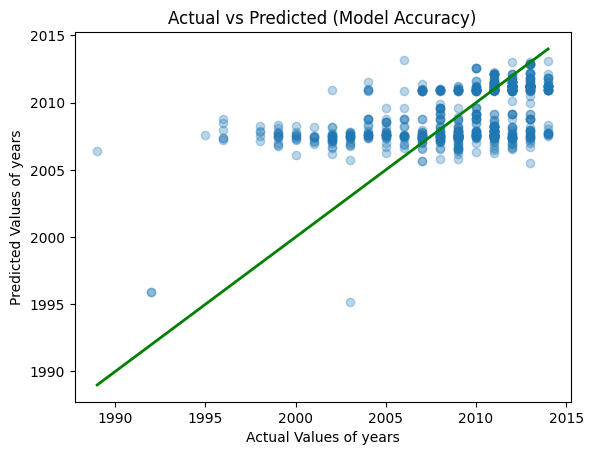

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing scatter plot
plt.scatter(x=y_train, y=y_lr_train_pred, alpha=0.3)

# Add the "Perfect Match" diagonal line
# This draws a line from the bottom-left to the top-right
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='green', lw=2)

plt.xlabel('Actual Values of years')
plt.ylabel('Predicted Values of years')
plt.title('Actual vs Predicted (Model Accuracy)')
plt.show()